# Loops

We have a list of odd numbers

`odds = [1, 3, 5, 7]`

In [2]:
odds = [1, 3, 5, 7, 8, 16]

How would I check if these numbers are odd?

We could inspect them manually or base our code on the known length of the list. How do we generalise this?

In [ ]:
print(odds[0])
print(odds[1])
print(odds[2])
print(odds[3])

A bad approach for three reasons

**Not scalable**. Imagine you need to print a list that has hundreds of elements. It might be easier to type them in manually.

**Difficult to maintain**. If we want to decorate each printed element with an asterisk or any other character, we would have to change four lines of code. While this might not be a problem for small lists, it would definitely be a problem for longer ones.

**Fragile**. If we use it with a list that has more elements than what we initially envisioned, it will only display part of the list’s elements. A shorter list, on the other hand, will cause an error because it will be trying to display elements of the list that do not exist.

In [ ]:
odds = [1, 3, 5]
print(odds[0])
print(odds[1])
print(odds[2])
print(odds[3])

In [ ]:
odds = [1, 3, 5, 7]
for num in odds:
    print(num)

In [ ]:
odds = [1, 3, 5, 7, 9, 11]
for num in odds:
    print(num)

`for variable in collection:`
    # do things using variable, such as print
Notice the indentation!
Python will do it for you.


The `num` after `for` could be anything.

We call it `num` as a mnemonic in this case.

If we replace it with, let's say banana, it will output the same results. Python is variable-naming agnostic.

In [ ]:
odds = [1, 3, 5, 7, 9, 11]
for banana in odds:
    print(banana)

Any collection of data can be iterated over.

For example, how would I go about printing all values I stored in a dictionary?

Loops can also be used to update a variable as we process it, or when we traverse a file.

In [6]:
length = 0
names = ['Alberts', 'Lehninger', 'Lovelace']
for value in names:
    length = length + 1
print('There are', length, 'names in the list.')
# how would I print this as an f-string?

There are 3 names in the list.


Variable values are still kept at the end of a loop. So what's the value of `names` after our loop?

Lots of functions (as we keep saying) are so commonly built by coders that Python now bakes them into its own functions.

What if we want to iterate over the length of a string? Or using intermediate steps?

In [ ]:
for i in range(10,20,0.5):
  print(i)

Unfortunately intermediate steps are not built in, as range accepts integeters. How can we solve this?

In [ ]:
for i in range(20, 40):  # 10 → 20, 20 → 40
    print(i / 2)

In [ ]:
i = 10
while i < 20:
    print(i)
    i += 0.5

Or we could use numpy.

Why don't we use numpy for everything?

In [ ]:
import numpy as np
for i in np.arange(10, 20, 0.5):
    print(i)

We can use loops to replicate the functioning of built-in functions, for example exponentiation.

print(5 ** 3)

Write a loop that calculates the sum of elements in a list by adding each element and printing the final value, so [124, 402, 36] prints 562

Let's retrieve more inflammation data from our FTP server.

In [ ]:
!wget ftp://orengoftp.biochem.ucl.ac.uk/ucbtnb4/data/inflammation-*.csv

As a final piece to processing our inflammation data, we need a way to get a list of all the files in our data directory whose names start with `inflammation-` and end with `.csv`. The following library will help us to achieve this:

**glob**

The glob library contains a function, also called glob, that finds files and directories whose names match a pattern. We provide those patterns as strings: the character `*` matches zero or more characters, while `?` matches any one character. We can use this to get the names of all the CSV files in the current directory:

In [14]:
import glob

In [ ]:
print(glob.glob('inflammation*.csv'))

What's the type of data outputted by glob.glob?

In [ ]:
filenames = glob.glob('inflammation*.csv')
print(type(filenames))

As these examples show, `glob.glob`’s result is a list of file and directory paths in arbitrary order. This means we can loop over it to do something with each filename in turn. In our case, the “something” we want to do is generate a set of plots for each file in our inflammation dataset.

If we want to start by analyzing just the first three files in alphabetical order, we can use the sorted built-in function to generate a new sorted list from the `glob.glob` output:

In [ ]:
import glob
import numpy
import matplotlib.pyplot

filenames = sorted(glob.glob('inflammation*.csv'))
filenames = filenames[0:3]
for filename in filenames:
    print(filename)

    data = numpy.loadtxt(fname=filename, delimiter=',')

    fig = matplotlib.pyplot.figure(figsize=(10.0, 3.0))

    axes1 = fig.add_subplot(1, 3, 1)
    axes2 = fig.add_subplot(1, 3, 2)
    axes3 = fig.add_subplot(1, 3, 3)

    axes1.set_ylabel('average')
    axes1.plot(numpy.mean(data, axis=0))

    axes2.set_ylabel('max')
    axes2.plot(numpy.amax(data, axis=0))

    axes3.set_ylabel('min')
    axes3.plot(numpy.amin(data, axis=0))

    fig.tight_layout()
    matplotlib.pyplot.show()

Now that we have more datasets, let's plot the difference between the average inflammations reported in the first and second datasets (stored in inflammation-01.csv and inflammation-02.csv, etc.), i.e., the difference between the leftmost plots of the first two figures.

In [ ]:
import glob
import numpy
import matplotlib.pyplot

filenames = sorted(glob.glob('inflammation*.csv'))

data0 = numpy.loadtxt(fname=filenames[0], delimiter=',')
data1 = numpy.loadtxt(fname=filenames[1], delimiter=',')

fig = matplotlib.pyplot.figure(figsize=(10.0, 3.0))

matplotlib.pyplot.ylabel('Difference in average')
matplotlib.pyplot.plot(numpy.mean(data0, axis=0) - numpy.mean(data1, axis=0))

fig.tight_layout()
matplotlib.pyplot.show()

We are going to use this data to try to prove some data fabrication.
Let's use each of the files once to generate a dataset containing values averaged over all patients by completing the code inside the loop given below:


In [ ]:
#filenames = glob.glob('inflammation*.csv')
#composite_data = numpy.zeros((60, 40))
#for filename in filenames:
    # sum each new file's data into composite_data as it's read
    #
# and then divide the composite_data by number of samples
#composite_data = composite_data / len(filenames)

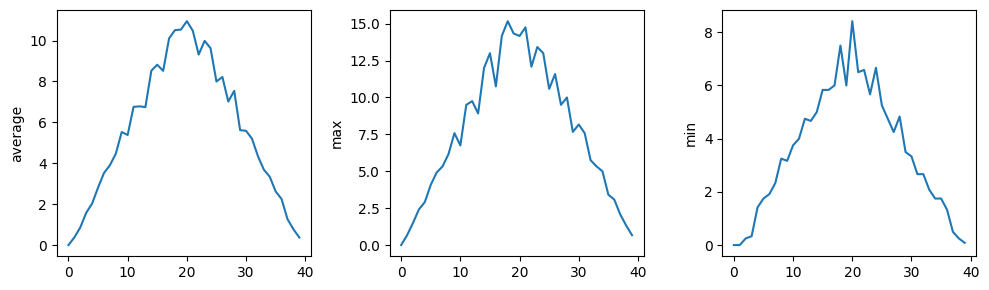

In [18]:
import glob
import numpy
import matplotlib.pyplot

filenames = glob.glob('inflammation*.csv')
composite_data = numpy.zeros((60, 40))

for filename in filenames:
    data = numpy.loadtxt(fname = filename, delimiter=',')
    composite_data = composite_data + data

composite_data = composite_data / len(filenames)

fig = matplotlib.pyplot.figure(figsize=(10.0, 3.0))

axes1 = fig.add_subplot(1, 3, 1)
axes2 = fig.add_subplot(1, 3, 2)
axes3 = fig.add_subplot(1, 3, 3)

axes1.set_ylabel('average')
axes1.plot(numpy.mean(composite_data, axis=0))

axes2.set_ylabel('max')
axes2.plot(numpy.amax(composite_data, axis=0))

axes3.set_ylabel('min')
axes3.plot(numpy.amin(composite_data, axis=0))

fig.tight_layout()

matplotlib.pyplot.show()

# Moving on to conditionals.
During earlier classes we introduced them


*   Equal ==
*   Greater than >
*   Greater or equal to >=
*   Less than <
*   Less or equal to <=
*   Not equal !=

One of the most used checks (for lengths, identity and so on), an `if/elif/else` condition check can steer our code towards different behaviour.



In [ ]:
num = 37
if num > 100:
    print('greater')
else:
    print('not greater')
print('done')

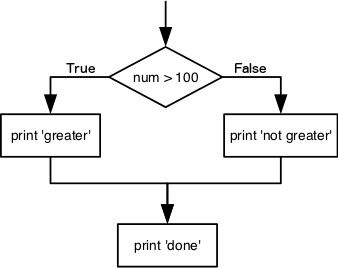

The second line of this code uses the keyword if to tell Python that we want to make a choice. If the test that follows the if statement is true, the body of the `if` (i.e., the set of lines indented underneath it) is executed, and “greater” is printed. If the test is false, the body of the else is executed instead, and “not greater” is printed. Only one or the other is ever executed before continuing on with program execution to print “done”:

**Conditional statements don’t have to include an else. If there isn’t one, Python simply does nothing if the test is false:**

In [ ]:
num = 53
print('before conditional...')
if num > 100:
    print(num, 'is greater than 100')
print('...after conditional')

We can also chain several tests together using elif, which is short for “else if”. The following Python code uses elif to print the sign of a number.

In [ ]:
num = -3

if num > 0:
    print(num, 'is positive')
elif num == 0:
    print(num, 'is zero')
else:
    print(num, 'is negative')

Conditions can be combined with boolean logic (or, and).

`and` is only true if both parts are true:

while `or` is true if at least one part is true:

In [ ]:
if (1 > 0) and (-1 >= 0):
    print('both parts are true')
else:
    print('at least one part is false')

In [ ]:
if (1 < 0) or (1 >= 0):
    print('at least one test is true')

Let's go back to our inflammation data.

In [ ]:
import numpy
data = numpy.loadtxt(fname='inflammation-01.csv', delimiter=',')

From the first couple of plots, we saw that maximum daily inflammation exhibits a strange behavior and raises one unit a day. Wouldn’t it be a good idea to detect such behavior and report it as suspicious? Let’s do that! However, instead of checking every single day of the study, let’s merely check if maximum inflammation in the beginning (day 0) and in the middle (day 20) of the study are equal to the corresponding day numbers.

In [ ]:
max_inflammation_0 = numpy.amax(data, axis=0)[0]
max_inflammation_20 = numpy.amax(data, axis=0)[20]

if max_inflammation_0 == 0 and max_inflammation_20 == 20:
    print('Suspicious looking maxima!')

In-place operations

In [ ]:
x = 1  # original value
x += 1 # add one to x, assigning result back to x
x *= 3 # multiply x by 3
print(x)

Write some code that sums the positive and negative numbers in a list separately, using in-place operators. Do you think the result is more or less readable than writing the same without in-place operators?

In [ ]:
positive_sum = 0
negative_sum = 0
test_list = [3, 4, 6, 1, -1, -5, 0, 7, -8]
for num in test_list:
    if num > 0:
        positive_sum += num
    elif num == 0:
        pass
    else:
        negative_sum += num
print(positive_sum, negative_sum)

Three words that can affect our loops.
`pass`, `continue` and `break`

A small summary.

*  Use `if` condition to start a conditional statement, `elif` condition to provide additional tests, and else to provide a default.

*  The bodies of the branches of conditional statements must be indented.

*  Use == to test for equality.
*  `X and Y` is only true if both X and Y are true.
*  `X or Y` is true if either X or Y, or both, are true.



# Functions

At this point, we’ve seen that code can have Python make decisions about what it sees in our data. What if we want to convert some of our data, like taking a temperature in Fahrenheit and converting it to Celsius. We could write something like this for converting a single number

In [ ]:
fahrenheit_val = 99
celsius_val = ((fahrenheit_val - 32) * (5/9))

In [ ]:
fahrenheit_val2 = 43
celsius_val2 = ((fahrenheit_val2 - 32) * (5/9))

Let's create a function that lets us do this calculation consistently.

In [ ]:
def explicit_fahr_to_celsius(temp):
    # Assign the converted value to a variable
    converted = ((temp - 32) * (5/9))
    # Return the value of the new variable
    return converted

def fahr_to_celsius(temp):
    # Return converted value more efficiently using the return
    # function without creating a new variable. This code does
    # the same thing as the previous function but it is more explicit
    # in explaining how the return command works.
    return ((temp - 32) * (5/9))



python-function.svg

In [ ]:
a_celsius = 24
b_fahrenheit = 95


Let's build two more functions. Celsius to Fahrenheit, and Celsius to Kelvin

Variables in functions are **local**, not **global**. What does it mean?

Now that we know how to wrap bits of code up in functions, we can make our inflammation analysis easier to read and easier to reuse. First, let’s make a visualize function that generates our plots:

In [22]:
def visualize(filename):

    data = numpy.loadtxt(fname=filename, delimiter=',')

    fig = matplotlib.pyplot.figure(figsize=(10.0, 3.0))

    axes1 = fig.add_subplot(1, 3, 1)
    axes2 = fig.add_subplot(1, 3, 2)
    axes3 = fig.add_subplot(1, 3, 3)

    axes1.set_ylabel('average')
    axes1.plot(numpy.mean(data, axis=0))

    axes2.set_ylabel('max')
    axes2.plot(numpy.amax(data, axis=0))

    axes3.set_ylabel('min')
    axes3.plot(numpy.amin(data, axis=0))

    fig.tight_layout()
    matplotlib.pyplot.show()

And another function that detects problematic data.

In [20]:
def detect_problems(filename):

    data = numpy.loadtxt(fname=filename, delimiter=',')

    if numpy.amax(data, axis=0)[0] == 0 and numpy.amax(data, axis=0)[20] == 20:
        print('Suspicious looking maxima!')
    elif numpy.sum(numpy.amin(data, axis=0)) == 0:
        print('Minima add up to zero!')
    else:
        print('Seems OK!')

Hold on, what about the `return` clause?

In [ ]:
filenames = sorted(glob.glob('inflammation*.csv'))

for filename in filenames[:3]:
    print(filename)
    visualize(filename)
    detect_problems(filename)

Let's document our functions and make our code readable.

In [24]:
def s(p):
    a = 0
    for v in p:
        a += v
    m = a / len(p)
    d = 0
    for v in p:
        d += (v - m) * (v - m)
    return numpy.sqrt(d / (len(p) - 1))

def std_dev(sample):
    sample_sum = 0
    for value in sample:
        sample_sum += value

    sample_mean = sample_sum / len(sample)

    sum_squared_devs = 0
    for value in sample:
        sum_squared_devs += (value - sample_mean) * (value - sample_mean)

    return numpy.sqrt(sum_squared_devs / (len(sample) - 1))

# KEY POINTS
*  Define a function using def function_name(parameter).
*  The body of a function must be indented.
*  Call a function using function_name(value).
*  Numbers are stored as integers or floating-point numbers.
*  Variables defined within a function can only be seen and used within the body of the function. These are local variables
*  Variables created outside of any function are called global variables.
Within a function, we can access global variables.
*  Variables created within a function override global variables if their names match.
*  Put docstrings in functions to provide help for that function.


# **Homework**

In the interest of time, at your own pace, please look into

* how to set up a default value to be returned by a function.
* How parameters can be passed by matching based on name, by position, or by omitting them (in which case the default value is used). (i.e. args and kwargs)

You're welcome to use LLMs or any source of information online.